# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 78     |  |
| :-------------|:-------------|
| Hugo Rutten   | 6541593 |
| Tijn Kraan    | 6566499      |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

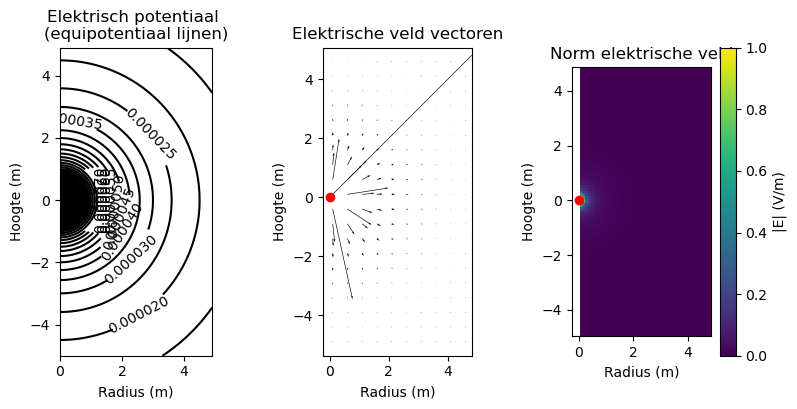

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Index voor z=0 is: 50


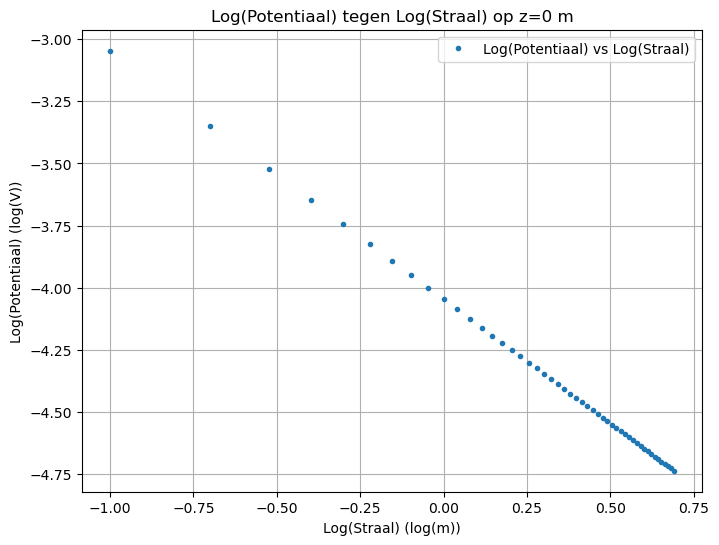

De exponent is: -1.00
-----Resultaten-----
De exponent van de log-log fit is: -1.0000
De verwachte exponent van de log-log fit is: -1.0000


In [3]:
#1. Bepaal welke index correspondeert met $z = 0$ m.
index_z0 = np.argmin(np.abs(z))
print(f"Index voor z=0 is: {index_z0}")

#2. Plot de log van het potentiaal tegen de log van de straal.
log_pot = np.log10(V[index_z0, 1:])
log_r = np.log10(r[1:])

plt.figure(figsize=(8, 6))
plt.plot(log_r, log_pot, '.', label='Log(Potentiaal) vs Log(Straal)')
plt.xlabel('Log(Straal) (log(m))')
plt.ylabel('Log(Potentiaal) (log(V))')
plt.title('Log(Potentiaal) tegen Log(Straal) op z=0 m')
plt.grid()
plt.legend()
plt.show()


#3. Fit de log van het potentiaal met de log van de straal.
coefficients = np.polyfit(log_r, log_pot, 1)
exponent = coefficients[0]
print(f"De exponent is: {exponent:.2f}")

#4. Print het exponent op een nette manier.
print("-----Resultaten-----")
print(f"De exponent van de log-log fit is: {exponent:.4f}")
print(f"De verwachte exponent van de log-log fit is: -1.0000")

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

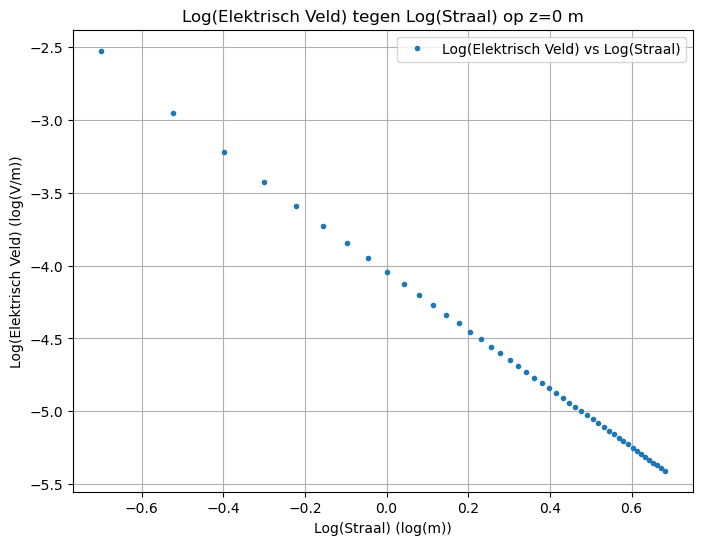

De exponent is: -2.04
-----Resultaten-----
De exponent van de log-log fit is: -2.0404
De verwachte exponent van de log-log fit is: -2.0000


In [4]:
idx_z0_E = np.argmin(np.abs(z_for_E))

#2. Plot de log van het elektrische veld tegen de log van de straal.
log_E = np.log10(normE[idx_z0_E, 1:])
log_r_E = np.log10(r_for_E[1:])

plt.figure(figsize=(8, 6))
plt.plot(log_r_E, log_E, '.' , label='Log(Elektrisch Veld) vs Log(Straal)')
plt.xlabel('Log(Straal) (log(m))')
plt.ylabel('Log(Elektrisch Veld) (log(V/m))')
plt.title('Log(Elektrisch Veld) tegen Log(Straal) op z=0 m')
plt.grid()
plt.legend()
plt.show()

#3. Fit de log van het elektrische veld met de log van de straal.
coefficients = np.polyfit(log_r_E, log_E, 1)
exponent = coefficients[0]
print(f"De exponent is: {exponent:.2f}")

#4. Print het exponent op een nette manier.
print("-----Resultaten-----")
print(f"De exponent van de log-log fit is: {exponent:.4f}")
print(f"De verwachte exponent van de log-log fit is: -2.0000")

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

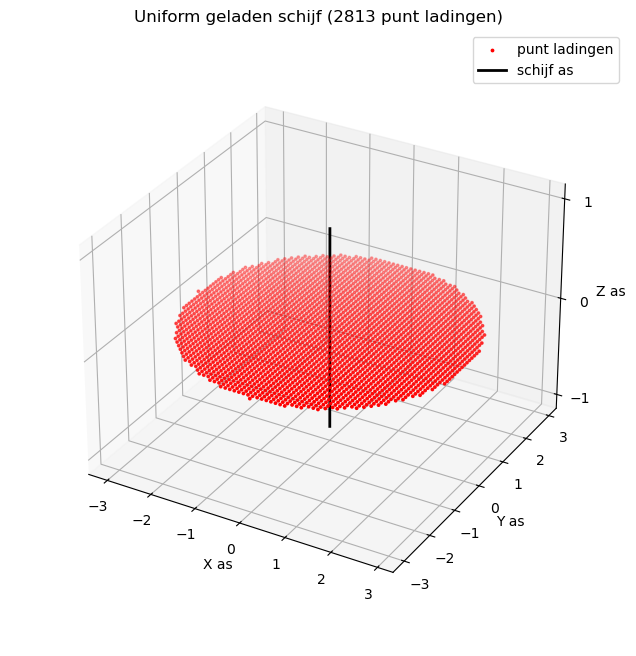

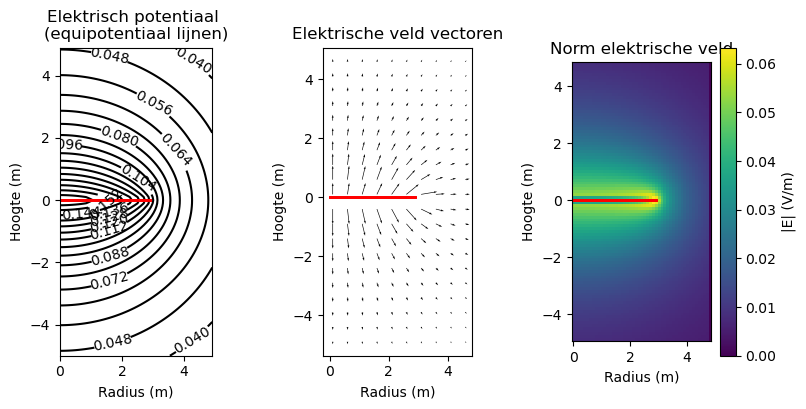

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1: De variabele disk radius bepaald hoe erg je inzoomt op de disk waarbij een lagere waarde meer ingezoomd is, als deze 0 is is het een puntlading. Bij hogere waardes duurt het langer om de code te laden.

2: De grid_step bepaalt de resolutie van het model en bepaalt de afstand tussen de punten in de grid. Waarbij een kleinere stapgrootte de nauwkeurigheid van de simulatie verhoogt. De laadtijd neemt kwadratisch af.

3: z_coord_DISK past de hoogte van de disk aan, in de eerste grafiek veranderd er niks aangezien de veldsterkte en lading van het veld niet afhangen van de hoogte. Wel veranderen de hoogtes in de onderste grafieken waardoor metingen verder van het veld af beter te meten zijn. De laadtijd wordt niet beinvloed door de waarde van z_coord_DISK.


#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
#Bereken en print de ladingsdichtheid sigma met een correcte eenheid.
sigma = number_point_charges_on_disk * charge_one_point / (np.pi * disk_radius**2)  # (C/m^2)
print(f"Ladingsdichtheid sigma: {sigma:.4e} C/m^2")

Ladingsdichtheid sigma: 9.9490e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0, 0.5, 'Potentiaal V (V)')

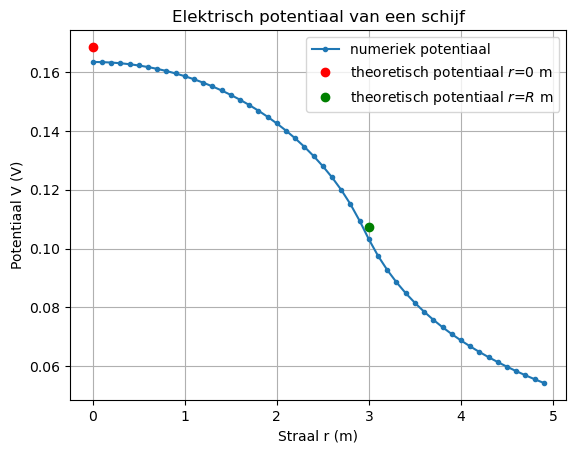

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.argmin(np.abs(z_for_E))

V_0 = sigma * disk_radius / (2 * epsilon0) # potentiaal op r = 0


V_R = sigma * disk_radius / (np.pi * epsilon0)  # potentiaal op de straal van de schijf
r_R = disk_radius  # straal van de schijf

r_plot = r
V_plot = V[idx_z_zero, :]

plt.title(f"Elektrisch potentiaal van een schijf")
plt.plot(r_plot, V_plot, ".-", label="numeriek potentiaal")
plt.plot(0, V_0, "ro", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "go", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.grid()
plt.xlabel("Straal r (m)")
plt.ylabel("Potentiaal V (V)")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


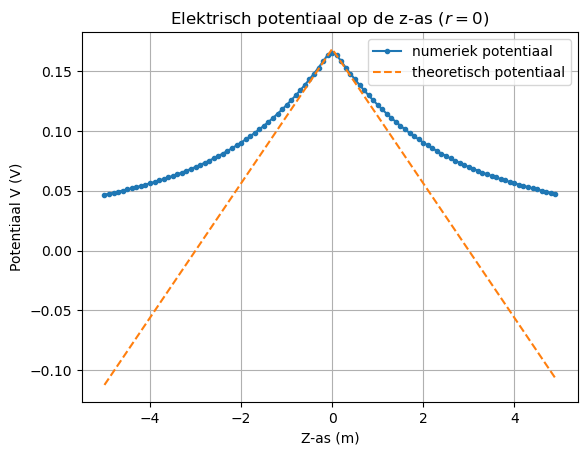

In [9]:
#Plot het numeriek berekend elektrische potentiaal op de z-as (r=0)
idx_r_zero = np.argmin(np.abs(r - 0))

z_plot = z
V_plot = V[:, idx_r_zero]

plt.title(f"Elektrisch potentiaal op de z-as ($r=0$)")
plt.plot(z_plot, V_plot, ".-", label="numeriek potentiaal")
plt.grid()
plt.xlabel("Z-as (m)")
plt.ylabel("Potentiaal V (V)")

#Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.

V_theoretical = sigma * (disk_radius - np.abs(z_plot)) / (2 * epsilon0)

plt.plot(z_plot, V_theoretical, "--", label="theoretisch potentiaal")
plt.legend()
plt.savefig("potentiaal_z_as_vergelijking.png", dpi=300)
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

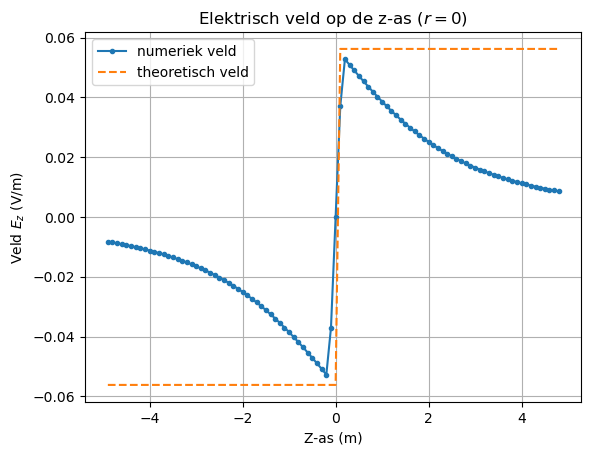

In [10]:
#Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$)
idx_r_zero = np.argmin(np.abs(r - 0))
z_plot = z[1:-1]  # we kunnen E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie
Ez_plot = Ez[:, idx_r_zero]
E_th = sigma / (2 * epsilon0) * np.sign(z_for_E)  # theoretisch elektrisch veld op de as van een schijf



plt.title(f"Elektrisch veld op de z-as ($r=0$)")
plt.plot(z_plot, Ez_plot, ".-", label="numeriek veld")
plt.plot(z_plot, E_th, "--", label="theoretisch veld")
plt.legend()
plt.grid()
plt.xlabel("Z-as (m)")
plt.ylabel("Veld $E_z$ (V/m)")
plt.savefig("elektrisch_veld_z_as_vergelijking.png", dpi=300)
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1: Wanneer de z waarde 0 nadert omdat het potentiaal en de lading naar 0 gaat wat ook gebeurt bij de plaat en dus vertonen ze daar hetzelfde gedrag. Ook lijkt vanaf daar de lading oneindig door te lopen waardoor de schijf zich als een uniforme lading gaat gedragen.

2: De theoretische waarde blijft gelijk voor |z|>0.1 maar de numerieke waarde neemt wel af, dit komt omdat bij het berekenen van de theoretische waarde de z waarde niet is gebruikt maar dit in het echt wel zo is. 
Voor |z|<0.1 zie je de theoretische waarde ongeveer recht omhoog gaan, maar de numerieke waarde niet. Dit komt door het verschild in de stapgrootte van de theoretische waardes en de numerieke waardes.

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

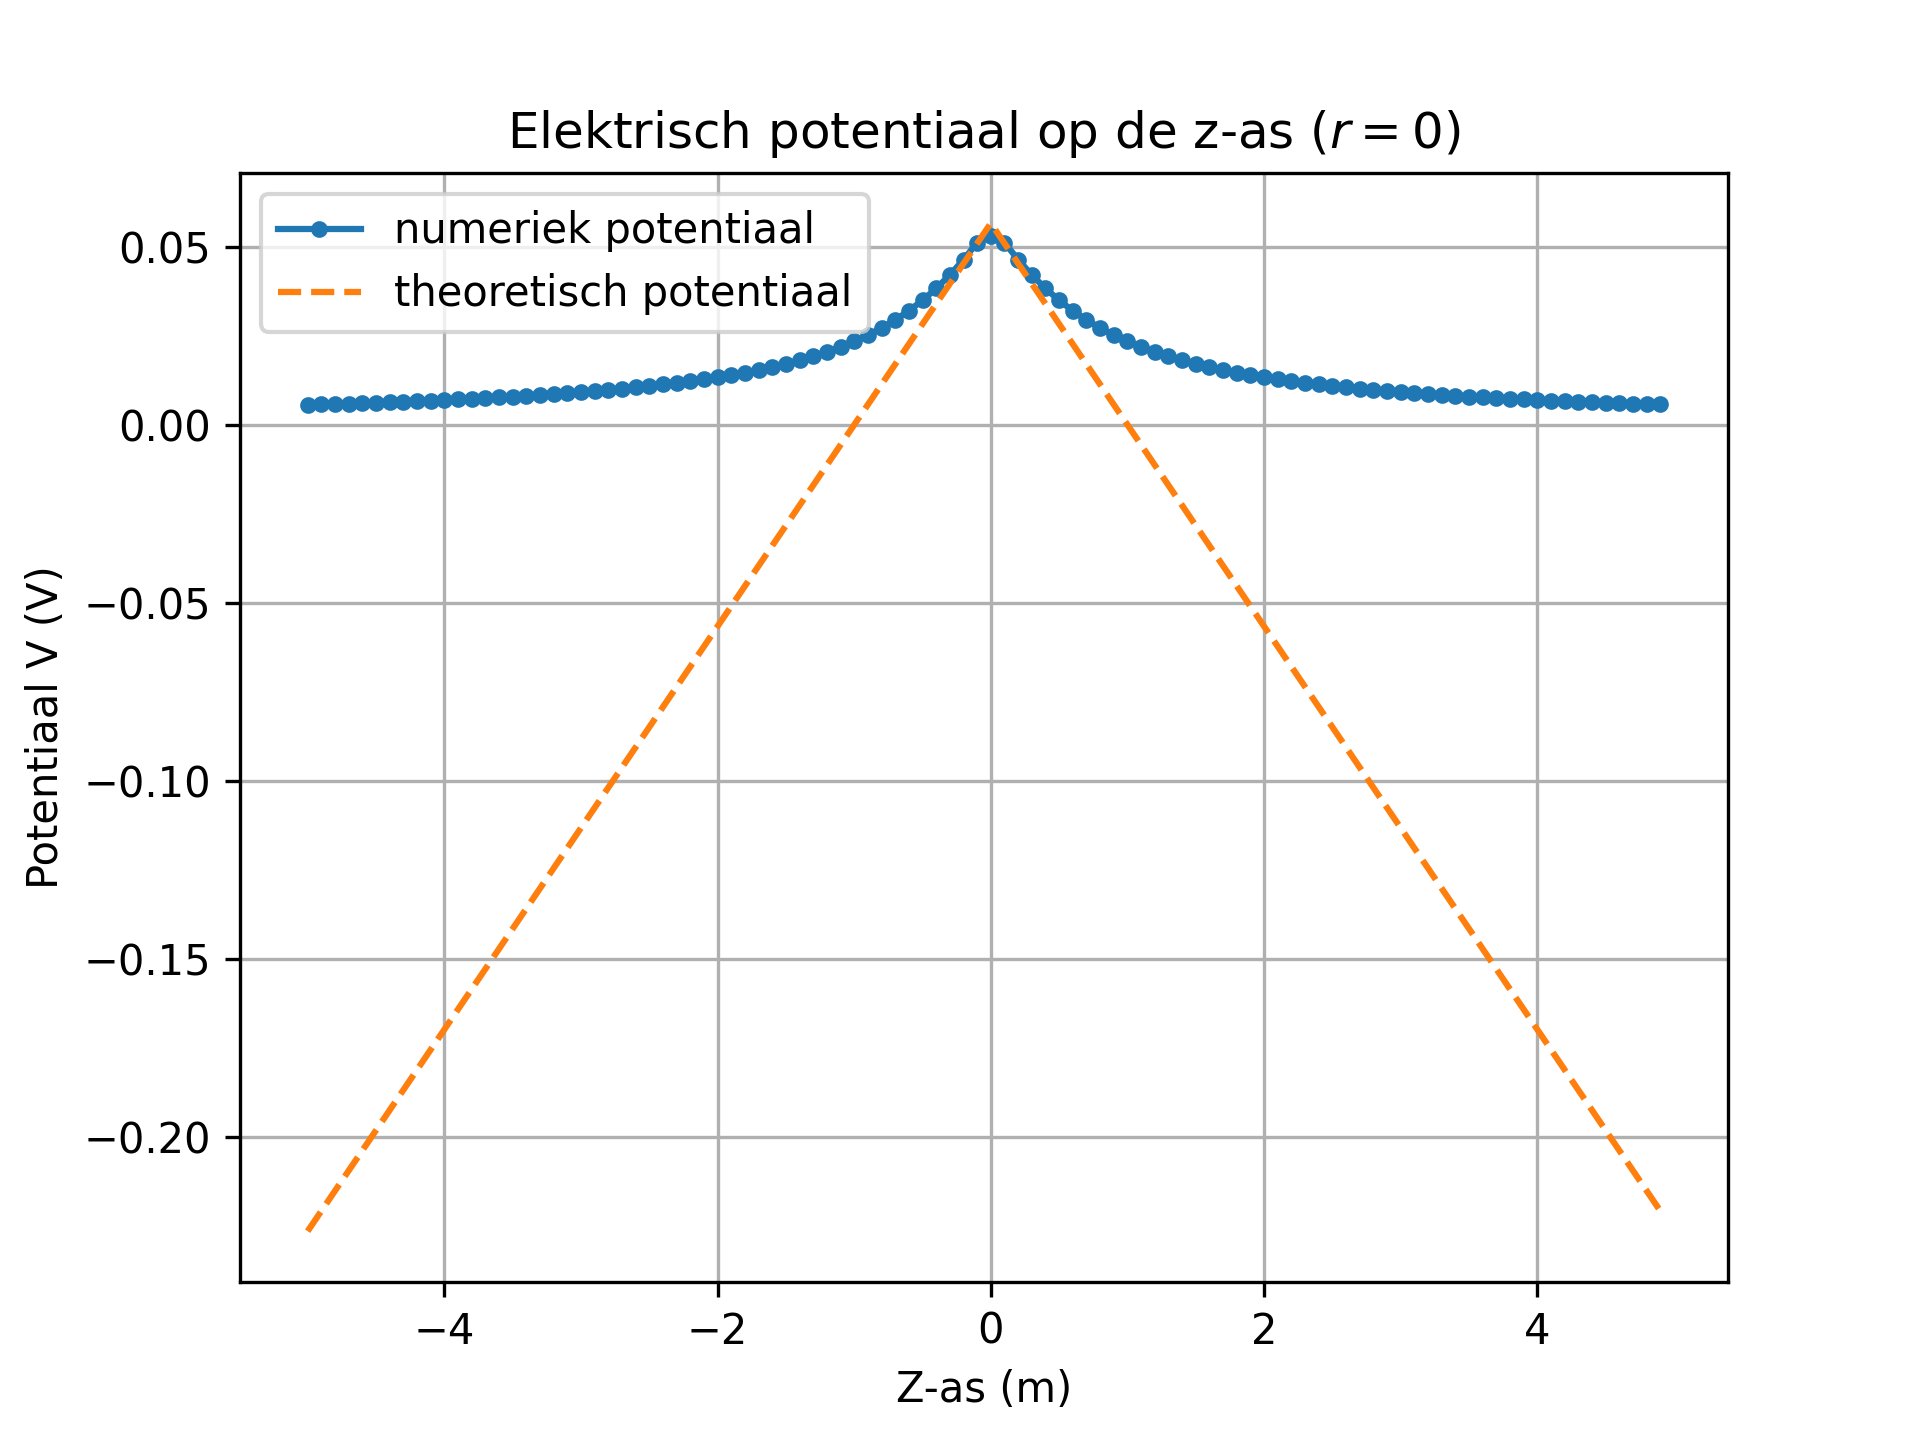

Figuur van 2d met straal 1 m
------------------------------
Figuur van 2e met straal 1 m


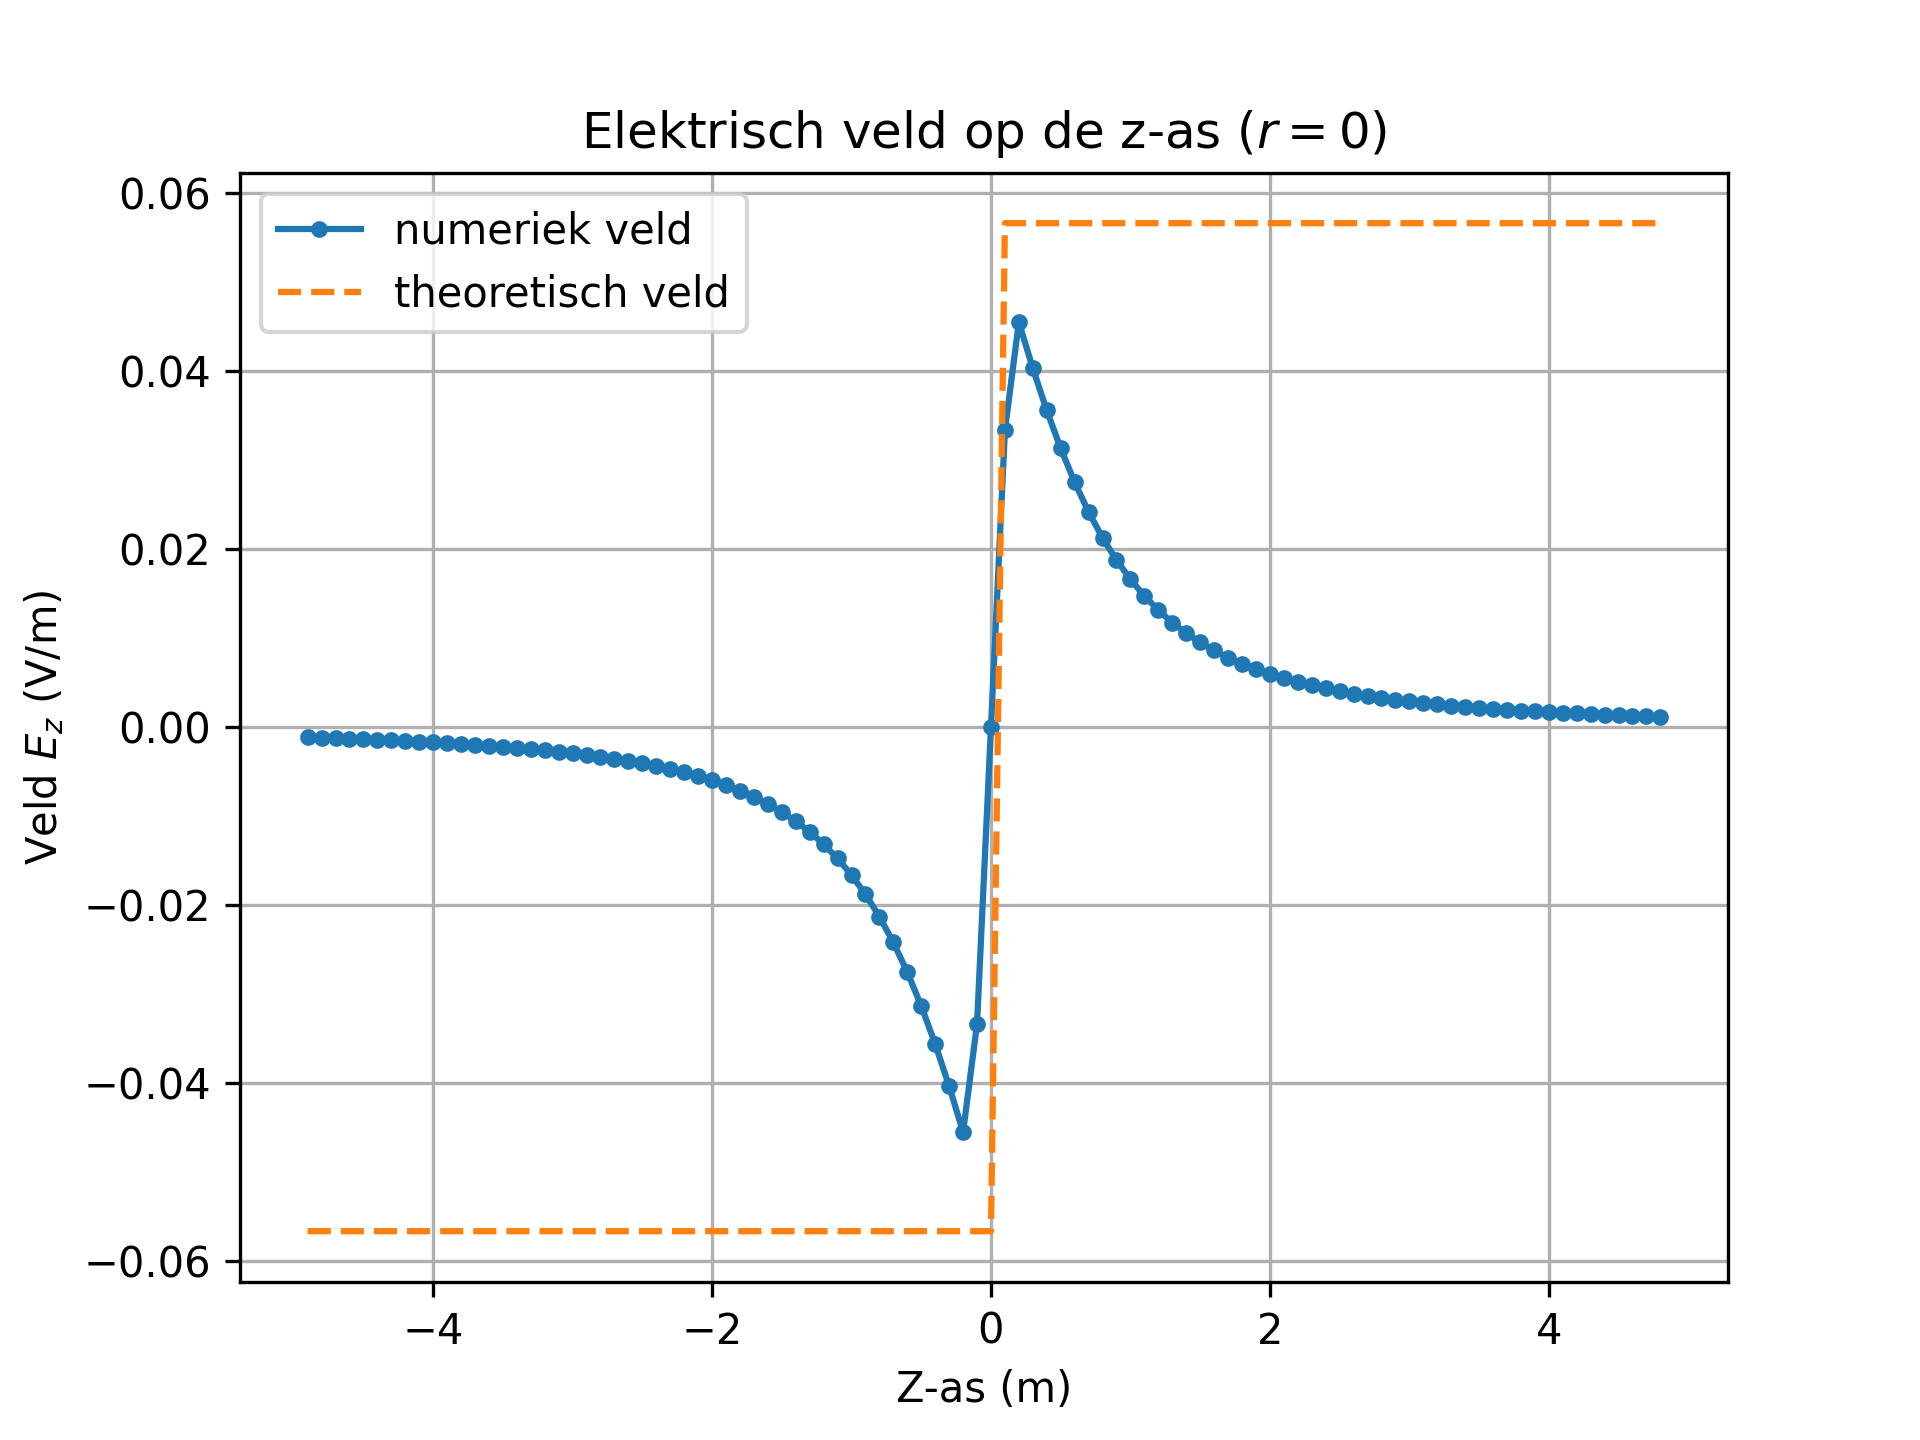

In [11]:


display(Image("potentiaal_z_as_vergelijking(2g).png"))

print("Figuur van 2d met straal 1 m")
print("------------------------------")
print("Figuur van 2e met straal 1 m")

display(Image("elektrisch_veld_z_as_vergelijking(2g).png"))

##### Antwoorden 2g

Figuur van 2d: Zowel de theoretische als de numerieke waardes van de grafiek bij een r van drie is 3 keer zo groot als de grafiek bij een r van één

Figuur van 2e: De theoretische waarde is hetzelfde, maar de pieken van de numerieke waardes zijn iets lager bij een straal van één in vergelijking met een straal van drie, het verschil is klein wat komt omdat de invloed van het stuk cirkel dat erbij komt vergeleken met wat er al was klein is. 

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

10 * E_1 = E_2

10 (1 - (z / sqrt(R^2 + z^2))) = 1

sqrt(R^2 + z^2) = 10 * z / 9

z = R * 9/sqrt(19)

voor r = 3 geeft z = 27 / sqrt(19) = 6.19 m

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

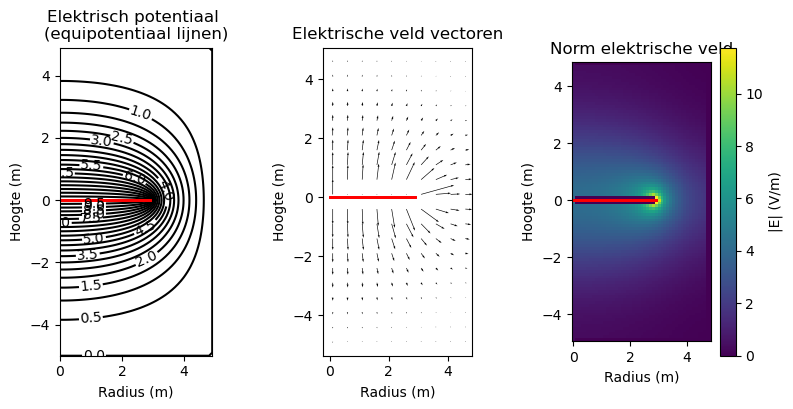

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

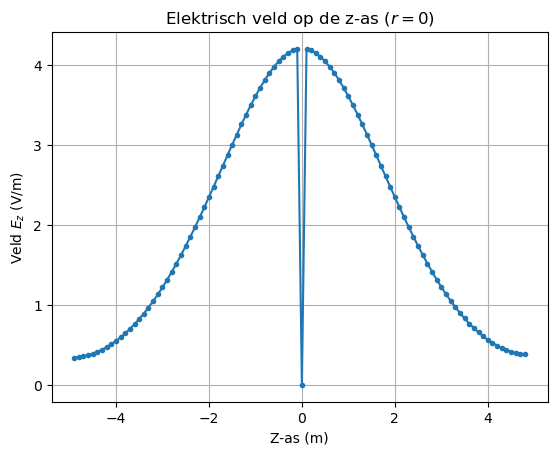

De norm is 1.52e-05 volt per meter voor de hoogte van -1.78e-14 meter


In [13]:
#Plot de elektrische veld sterkte op de as van de schijf.
idx_R = np.argmin(np.abs(r - 0))  # index van r=0 m
Ez_plot = Ez[:, idx_R]  # z-component van het elektrische veld op de as van de schijf

plt.title(f"Elektrisch veld op de z-as ($r=0$)")
plt.plot(z_for_E, np.abs(Ez_plot), ".-", label="numeriek veld")
plt.grid()
plt.xlabel("Z-as (m)")
plt.ylabel("Veld $E_z$ (V/m)")
plt.show()

print(f"De norm is {Ez_plot[49]:.2e} volt per meter voor de hoogte van {z_for_E[49]:.2e} meter")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

$$ \mathbf{\sigma} = {E_z2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg]^{-1}$$

Dit gaat door r->0 en z->0 naar de formule $$ \mathbf{\sigma} = {E_z2\epsilon_0}$$

In [14]:
sigma_2 = 2* epsilon0 * Ez_plot[49]  # ladingsdichtheid op de schijf (C/m^2)
print(f"Ladingsdichtheid sigma: {sigma_2:.4e} C/m^2")

Ladingsdichtheid sigma: 2.6942e-16 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


In [15]:
###
###Jouw code hier###
###

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.


##### Antwoord 3d.5

*Schrijf hier je argumentatie voor vraag 3d.5.*

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

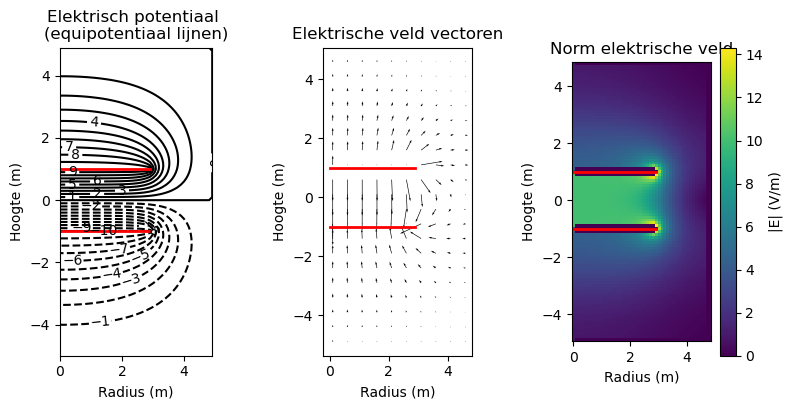

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


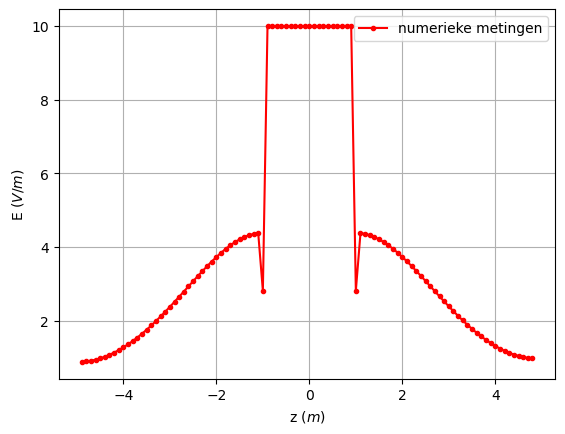

In [18]:
idx_r0 = np.argmin(np.abs(r_for_E))
Ez_r0 = Ez[:, idx_r0]
plt.figure()
plt.plot(z_for_E, np.abs(Ez_r0),'r.-' ,label='numerieke metingen')
plt.xlabel("z $(m)$")
plt.ylabel("E $(V/m)$")
plt.grid()
plt.legend()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1: Het theoretische elektrische veld tussen de platen is uniform en constant. Het theoretische elektrische veld buiten de platen is nul. Voor een elektrisch veld tussen 2 platen volgt uit E = -dV/dz dat Ez = -2V0/d. Dit is dus niet afhankelijk van de z dus het veld is uniform. Voor buiten de platen geldt dat E = sigma/2epsilon_0, maar deze 2 velden heffen elkaar op, waardoor er buiten de platen het elektrisch veld nul wordt

2: Het numeriek berekende elektrische veld op de as van de schijven is tussen de platen constant, maar buiten de platen is het elektrisch veld niet gelijk aan nul. Dus dit numerieke elektrische veld komt niet totaal overeen met het theoretische elektrische veld.

3: Bij de 2 platen is er een groter gebied waar het elektrische veld maximaal is. Ook is het elektrische veld van de 2 platen sterker en meer uniform, dus daar zijn makkelijker metingen aan te doen

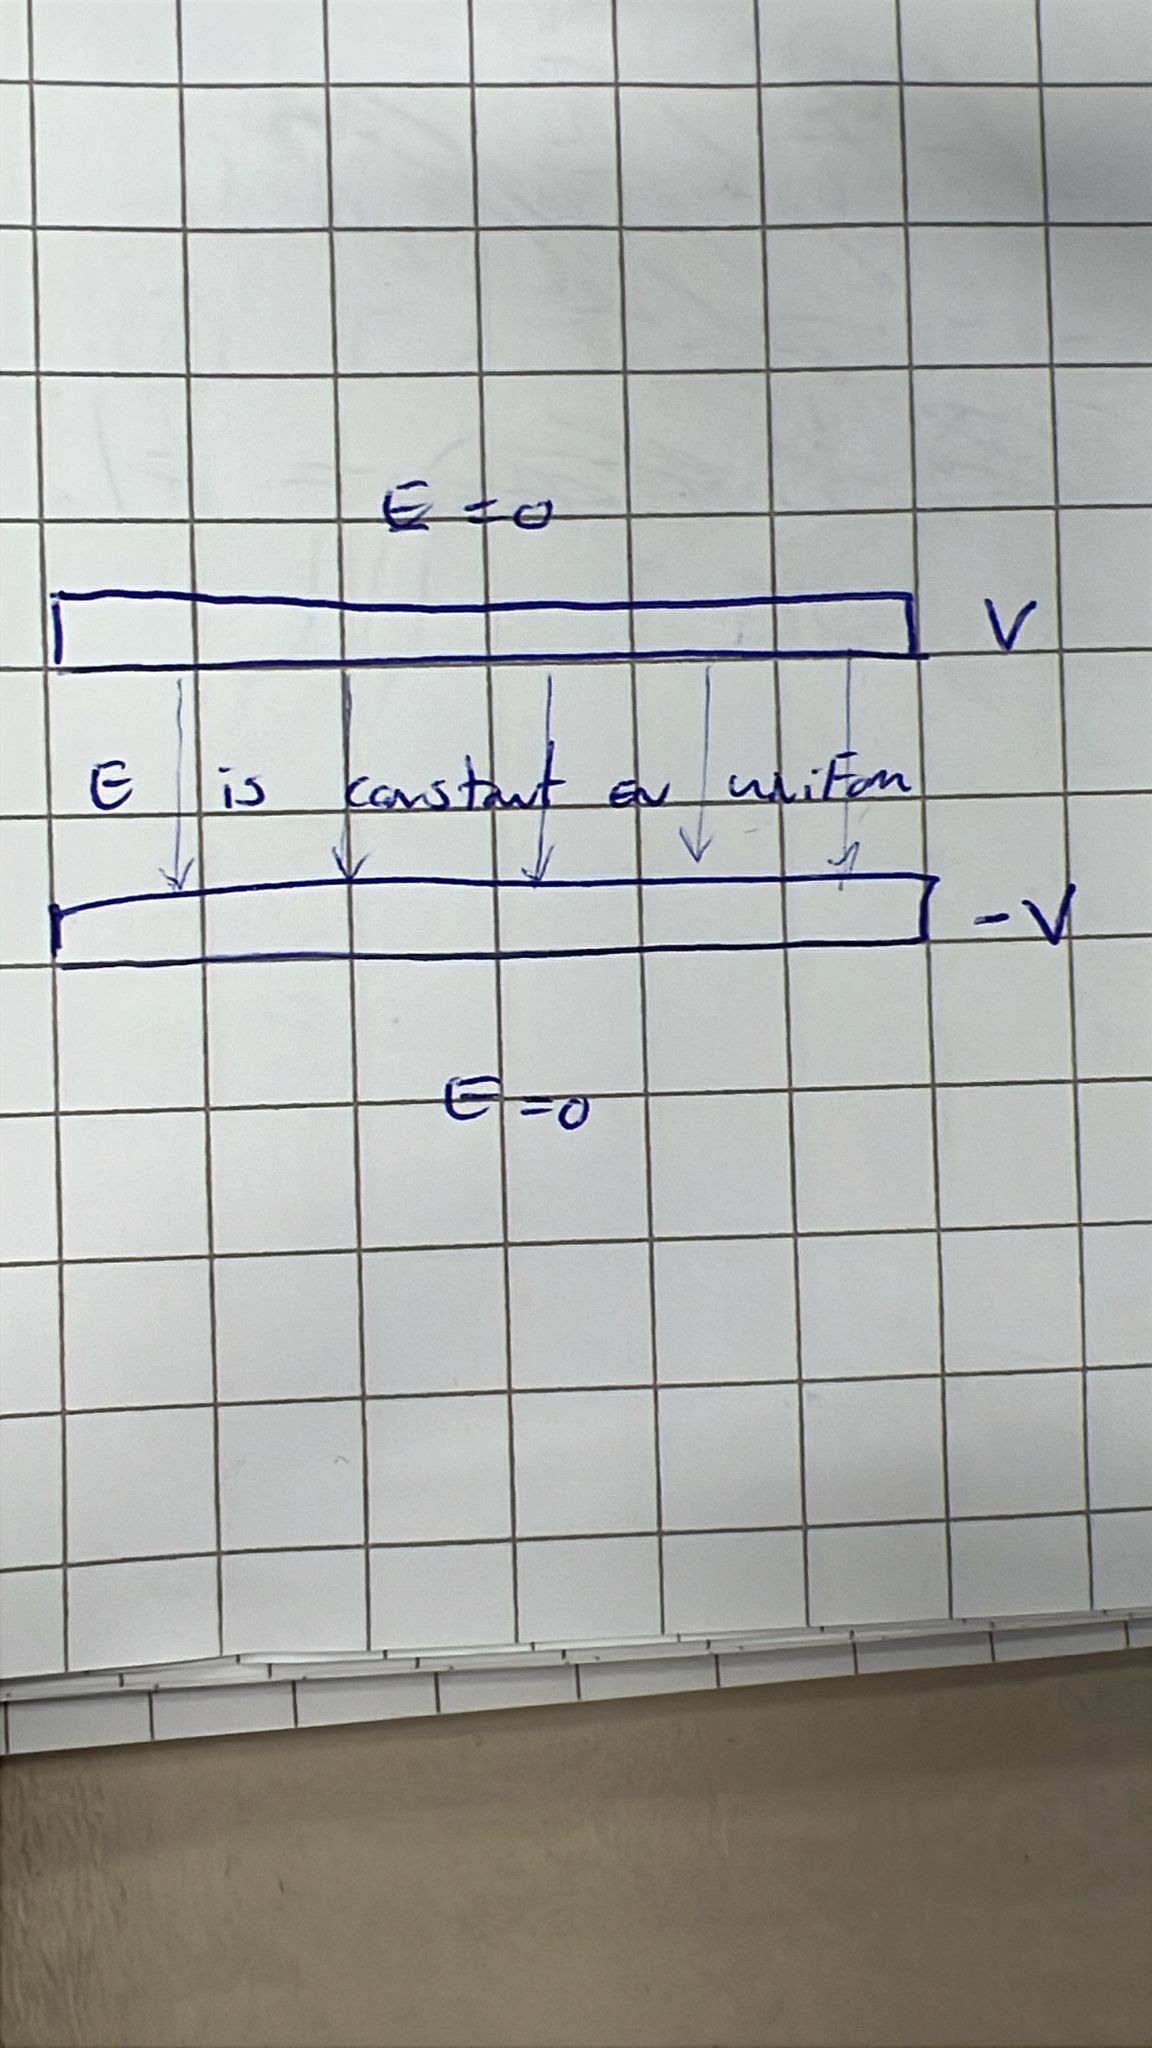

In [19]:
display(Image("SchetsElektrischVeld.jpeg"))

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
R = disk_radius
d = spacing_between_disks
V0 = V1  
A = np.pi * R**2
#oppervlakte lading
E_theorie = 2*V0/d
sigma = epsilon0 * E_theorie
#totale lading
Q = sigma * A
#capaciteit
C = epsilon0 * A / d

print(f"Oppervlakteladingsdichtheid σ = {sigma:.3e} C/m²")
print(f"Totale lading per schijf Q = {Q:.3e} C")
print(f"Capaciteit C = {C:.3e} F")

Oppervlakteladingsdichtheid σ = 8.854e-11 C/m²
Totale lading per schijf Q = 2.503e-09 C
Capaciteit C = 1.252e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1: In theorie is de oppervlaktelading aan de buitenkant van de schijven nul, want de 2 elektrische velden buiten de schijven heffen elkaar exact op. Dus ook op het buitenoppervlak. Echter is dit in deze numerieke simulatie niet het geval, want de schijven niet oneindig groot, waardoor de elektrische velden elkaar niet helemaal opheffen.

2: Het elektrisch veld in de buurt van het oppervlak van een geleider staat altijd loodrecht op het oppervlak. Dit is het geval bij de numerieke simulatie, maar in theorie is er geen oppervlaktelading aan de buitenkant dus dan zal er geen elektrisch veld zijn. Dit is terug te zien in de formule E_loodrecht = sigma/epsilon0. Als er geen oppervlaktelading is dan is er ook geen elektrisch veld.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [21]:
idx_r0 = 0
idx_r1 = 1
dz = grid_step
#onder schijf
Ez_onder = Ez[idx_r0, idx_z2 - 1]
sigma_onder = epsilon0 * Ez_onder
#boven schijf
Ez_boven = Ez[idx_r1, idx_z2 + 1]
sigma_boven = epsilon0 * Ez_boven

print(f"E_z onder schijf = {Ez_onder:.3e} V/m")
print(f"σ onder schijf  = {sigma_onder:.3e} C/m^2")
print(f"E_z boven schijf = {Ez_boven:.3e} V/m")
print(f"σ boven schijf  = {sigma_boven:.3e} C/m^2")

E_z onder schijf = 0.000e+00 V/m
σ onder schijf  = 0.000e+00 C/m^2
E_z boven schijf = 1.585e-01 V/m
σ boven schijf  = 1.404e-12 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1: Bij een werkelijke schijf is de lading niet uniform waardoor de berekende waarde anders is dan de waarde uit 4c

2: Vraag 4c beschouwt de schijven in een ideale staat, maar in werkelijkheid is de ladingsverdeling niet uniform. Dus de capaciteit in 4c is slechts een benadering.

3: Bij een kleinere afstand wordt het elektrische veld tussen de platen groter.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [22]:
def vlakkeplaat(A,d,epsilonr):
    C = (A*epsilon0*epsilonr)/d
    return C

def cilinder(L,a,b,epsilonr):
    C = (2*np.pi*epsilon0*epsilonr*L)/np.log(b/a)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [23]:
#1
cap_a = vlakkeplaat(0.01,0.001,1.0006)
print(f"De capaciteit bij vraag 5b.1 is {cap_a:.3e} F")
#2
cap_b = cilinder(0.1,0.009,0.010,1.0006)
print(f"De capaciteit bij vraag 5b.2 is {cap_b:.3e} F")
#3
cap_c = vlakkeplaat(0.01,0.0005,1.0006)
print(f"De capaciteit bij vraag 5b.3 is {cap_c:.3e} F")
#4
cap_d = vlakkeplaat(0.01,0.001,78.5)
print(f"De capaciteit bij vraag 5b.4(1) is {cap_d:.3e} F")
cap_e = cilinder(0.1,0.009,0.010,78.5)
print(f"De capaciteit bij vraag 5b.4(2) is {cap_e:.3e} F")
#5
cap_f = vlakkeplaat(0.01,0.001,4)
print(f"De capaciteit bij vraag 5b.1 is {cap_f:.3e} F")
cap_g = cilinder(0.1,0.009,0.010,4)
print(f"De capaciteit bij vraag 5b.2 is {cap_g:.3e} F")

De capaciteit bij vraag 5b.1 is 8.859e-11 F
De capaciteit bij vraag 5b.2 is 5.283e-11 F
De capaciteit bij vraag 5b.3 is 1.772e-10 F
De capaciteit bij vraag 5b.4(1) is 6.950e-09 F
De capaciteit bij vraag 5b.4(2) is 4.145e-09 F
De capaciteit bij vraag 5b.1 is 3.542e-10 F
De capaciteit bij vraag 5b.2 is 2.112e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [24]:
#1
C = 0.001 #F
a = 0.005 #m
b = 0.006 #m
epsilonr = 1.006
L = (C*np.log(b/a))/2*np.pi*epsilon0*epsilonr
print(f"Bij vraag 5d.1 is de lengte L = {L:.3e}")

#2
br = 0.006 #m
d = 0.0005 #m
L2 = ((C*d)/epsilon0*epsilonr)/br
print(f"Bij vraag 5d.2 is de lengte L = {L2:.3e}")

Bij vraag 5d.1 is de lengte L = 2.551e-15
Bij vraag 5d.2 is de lengte L = 9.468e+06


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1: De antwoorden van 5c zijn niet realistisch, de eerste is heel klein en de tweede is heel groot. 

2: Dit probleem is opgelost door het oppervlak van de condensatoren te vergroten. Dit kan bijvoorbeeld met behulp van lagen.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [25]:
#2
m = 1500 + 6*75 #kg
v = 70/3.6 #m/s
E_kin = 0.5*m*v**2

E_tot = E_kin
print(f"De totale energie op het karretje is {E_tot:.3e} J")

#3
V = 10e3 #V
C = 2*E_kin/V**2
print(f"De totale capaciteit van de condensator is {C:.3e} F")

#4
d = 0.001 #
epsilonr = 87.5 
A = C*d/(epsilon0*epsilonr)
print(f"Het benodigde oppervlak hiervoor is {E_tot:.3e} m^2")



De totale energie op het karretje is 3.686e+05 J
De totale capaciteit van de condensator is 7.373e-03 F
Het benodigde oppervlak hiervoor is 3.686e+05 m^2


##### Antwoorden 5e

1: Een karretje zal ongeveer 1500 kg wegen zonder personen erin. Voor de gemiddelde massa van een persoon wordt 75 kg ingeschat.

6: Dit is niet realistisch, want het benodigde oppervlak is te groot. Dit is op te lossen door bijvoorbeeld condensatoren in serie te schakelen of condensatoren te stapelen.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

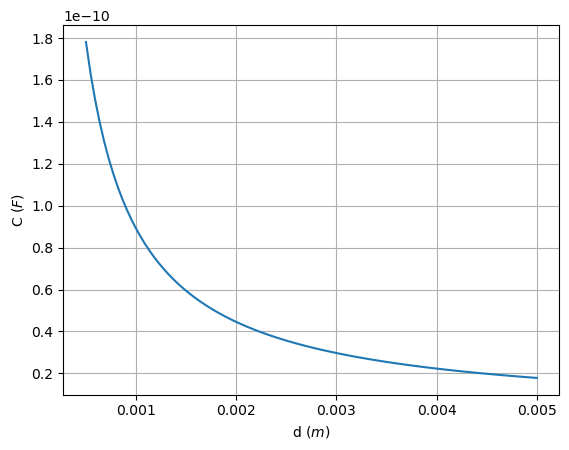

C:\Users\hugow\AppData\Local\Temp\ipykernel_23612\1632031452.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  C = (2*np.pi*epsilon0*epsilonr*L)/np.log(b/a)


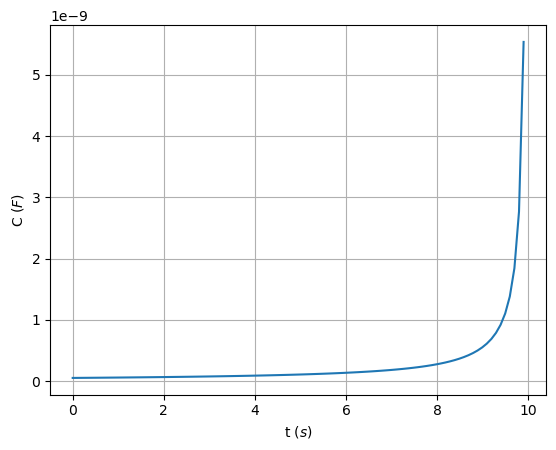

In [26]:
#1
A_plaat = 0.10 * 0.10
d_waardes = np.linspace(0.0005, 0.005, 100)
C_plaat = [vlakkeplaat(A_plaat, d,1.006) for d in d_waardes]

plt.figure()
plt.plot(d_waardes, np.array(C_plaat))
plt.xlabel("d $(m)$")
plt.ylabel("C $(F)$")
plt.grid()
plt.show()

#2
Lengte = 0.10
a_start = 0.009
b = 0.010
t = np.linspace(0, 10, 100)
a_values = np.linspace(0.009, 0.010, 100)
C_cil = [cilinder(Lengte, a, b,1.006) for a in a_values]


plt.plot(t, np.array(C_cil))
plt.xlabel("t $(s)$")
plt.ylabel("C $(F)$")
plt.grid()
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](opstellingdigiopdracht.jpeg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

![figure.schetsnieuwontwerp](schetsnieuwontwerp.jpeg)

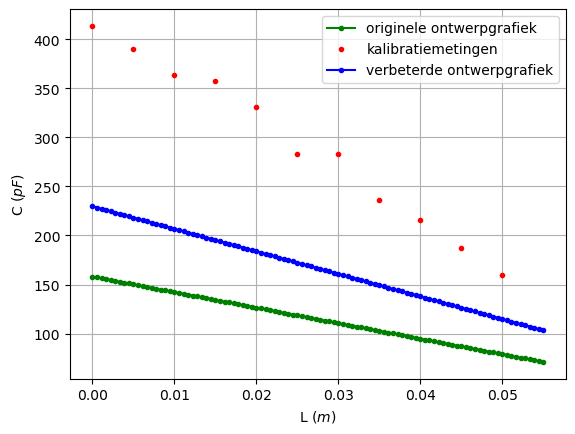

In [27]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie
L_min = 0
L_max = 0.055
dikte_karton2 = 0.00077068
breedte = 0.1
epsilon_karton = 2.0
L_array = np.linspace(L_min, L_max, 100)
A_array = breedte * (0.1 - L_array)
def ontwerpfunctie(L,dikte,epsilonr):
    L_overlap = 0.1 - L
    C = vlakkeplaat(L_overlap*breedte,dikte,epsilonr)
    return C

## Maak hier je plot
dikte_karton = 0.00112


L = np.array([0,0.01, 0.03, 0.02,0.04,0.05,0.045,0.035,0.025,0.015,0.005])
C = np.array([413.6,363.2,282.6,330.7,215.5,159.3,187.6,235.9,283.5,357.7,390.1 ])

plt.figure()
plt.plot(L_array,ontwerpfunctie(L_array,dikte_karton,epsilon_karton)*10**12,'g.-', label='originele ontwerpgrafiek')
plt.plot(L,C,'r.' ,label="kalibratiemetingen") 
plt.plot(L_array,ontwerpfunctie(L_array,dikte_karton2,epsilon_karton)*10**12,'b.-', label='verbeterde ontwerpgrafiek')
plt.grid()
plt.legend()
plt.xlabel('L $(m)$')
plt.ylabel('C $(pF)$')
plt.show()

##### Antwoorden 6a

De aangepaste ontwerpgrafiek levert een hogere capaciteit dan de originele ontwerpgrafiek. Dit is te verklaren doordat de originele analyse een dikkere kartonlaag gebruikte. De capaciteit neemt namelijk af als de tussenlaag dikker wordt.

Ook is te zien dat de verbeterde ontwerpgrafiek niet goed overeenkomt met de gemeten waardes. Dit heeft een aantal mogelijke verklaringen. Ten eerste ligt epsilonr tussen 1.7 en 3.0 voor karton. Bij deze analyse is een waarde van 2 gebruikt, maar deze kan in werkelijkheid anders zijn en dat heeft invloed op het resultaat. Ook kan het zijn dat er lucht tussen de platen is blijven zitten, waardoor de epsilonr niet overeenkomt. Ook wordt in de analyse aangegaan van een ideale condensator, terwijl dit in werkelijkheid niet het geval is.


#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [28]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [29]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*